# MPPP Processing

An Image object represents an image, processing would be done using the image array amd metadata stored as attributes in the image object. If the image is processed, the processed array could be accessed throught the attribute ```.im8``` of the image object.


An ImProcessor represents and image processor object. It is initiated by providing it with a json config file. An example file could be found in ```./params/image_processing_config.json```. To process a list of images, use the function ```process_images()```.

First initialise a processor object by passing in a file path to the json config file for the processor. This config file should specify the file_extension, boolean flags for saving the different components, lower bound clip values and scales used.

In [1]:
from src2.Image import Image, Frame
from src2.ImProcessor import ImProcessor

# create a processor object
processor = ImProcessor("./params/image_processing_config.json")

Finds all the files that corresponds to the target sol and process by every 10 sols. To process all the images, provide a list of file paths, the output directory to save the processed images and the suffix to be used in naming the output csv file

Processing Sols 05** in ../data/zcam
987 images

Number of images: 987
0 opened ZL0_0501_0711409376_943RAD_N0261004ZCAM03014_048085A01.IMG
saved ../images/sols_0500-0599_sci/ZL0_0501_0711409376_943RAD_N0261004ZCAM03014_048085A01.png
1 opened ZL0_0501_0711409411_784RAD_N0261004ZCAM03402_110085A01.IMG
saved ../images/sols_0500-0599_sci/ZL0_0501_0711409411_784RAD_N0261004ZCAM03402_110085A01.png
2 opened ZL0_0501_0711409411_784RAD_N0261004ZCAM03402_110085A02.IMG
saved ../images/sols_0500-0599_sci/ZL0_0501_0711409411_784RAD_N0261004ZCAM03402_110085A02.png
3 opened ZL0_0501_0711409483_785RAD_N0261004ZCAM03402_1100LMA01.IMG
saved ../images/sols_0500-0599_sci/ZL0_0501_0711409483_785RAD_N0261004ZCAM03402_1100LMA01.png
4 opened ZL0_0501_0711417145_988RAD_N0261004ZCAM03403_110085A01.IMG
saved ../images/sols_0500-0599_sci/ZL0_0501_0711417145_988RAD_N0261004ZCAM03403_110085A01.png
5 opened ZL0_0501_0711417145_988RAD_N0261004ZCAM03403_110085A02.IMG
saved ../images/sols_0500-0599_sci/ZL0_0501_0711417

z:\Mastcam-Z\agisoft\MPPP\.venv\lib\site-packages\numpy\core\_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
z:\Mastcam-Z\agisoft\MPPP\.venv\lib\site-packages\numpy\core\_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
z:\Mastcam-Z\agisoft\MPPP\.venv\lib\site-packages\numpy\core\_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


23 images

Number of images: 23
0 opened FLF_0501_0711423517_041RAD_N0261154FHAZ02418_0A0295J01.IMG
saved ../images/sols_0500-0599_eng/FLF_0501_0711423517_041RAD_N0261154FHAZ02418_0A0295J01.png
1 opened FRF_0501_0711423517_041RAD_N0261154FHAZ02418_0A0295J01.IMG
saved ../images/sols_0500-0599_eng/FRF_0501_0711423517_041RAD_N0261154FHAZ02418_0A0295J01.png
2 opened NLF_0501_0711423475_096RAD_N0261154SAPP00601_0A00LLJ01.IMG
saved ../images/sols_0500-0599_eng/NLF_0501_0711423475_096RAD_N0261154SAPP00601_0A00LLJ01.png
3 opened NLF_0501_0711423715_491RAD_N0261154NCAM03501_0A0195J01.IMG
saved ../images/sols_0500-0599_eng/NLF_0501_0711423715_491RAD_N0261154NCAM03501_0A0195J01.png
4 opened NLF_0501_0711423715_491RAD_N0261154NCAM03501_0A1195J01.IMG
saved ../images/sols_0500-0599_eng/NLF_0501_0711423715_491RAD_N0261154NCAM03501_0A1195J01.png
5 opened NLF_0501_0711423861_851RAD_N0261154NCAM03501_0A0195J01.IMG
saved ../images/sols_0500-0599_eng/NLF_0501_0711423861_851RAD_N0261154NCAM03501_0A0195J01.

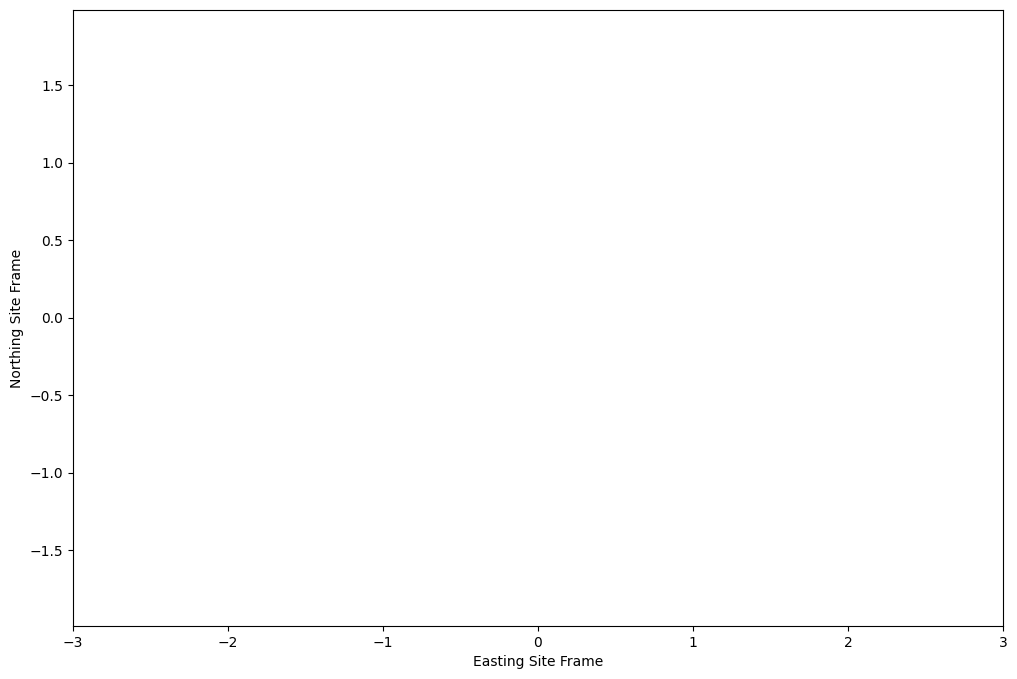

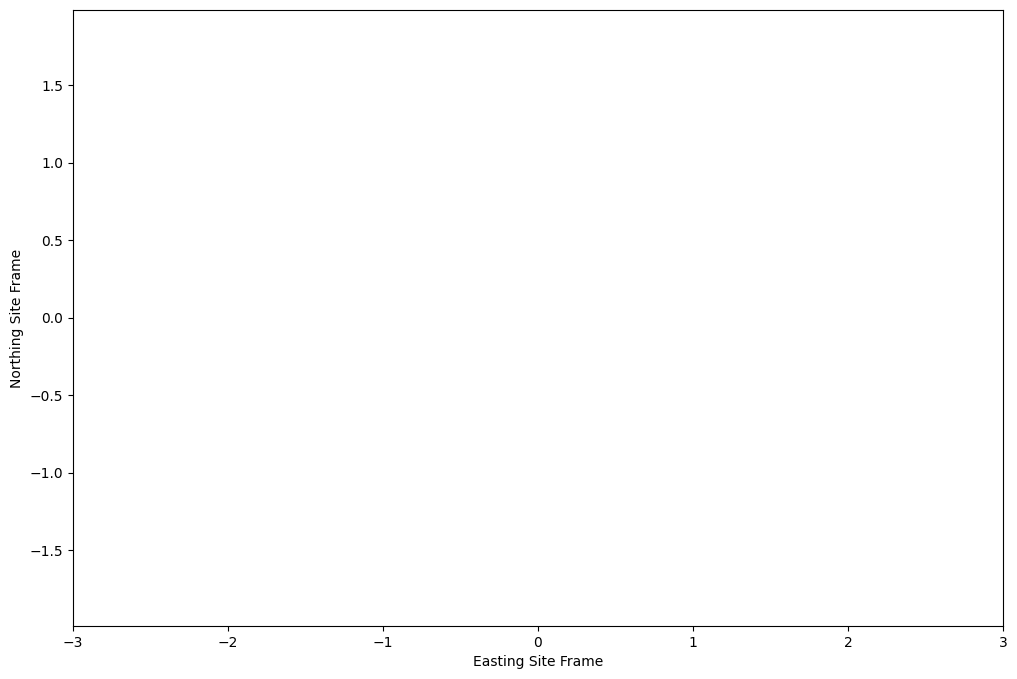

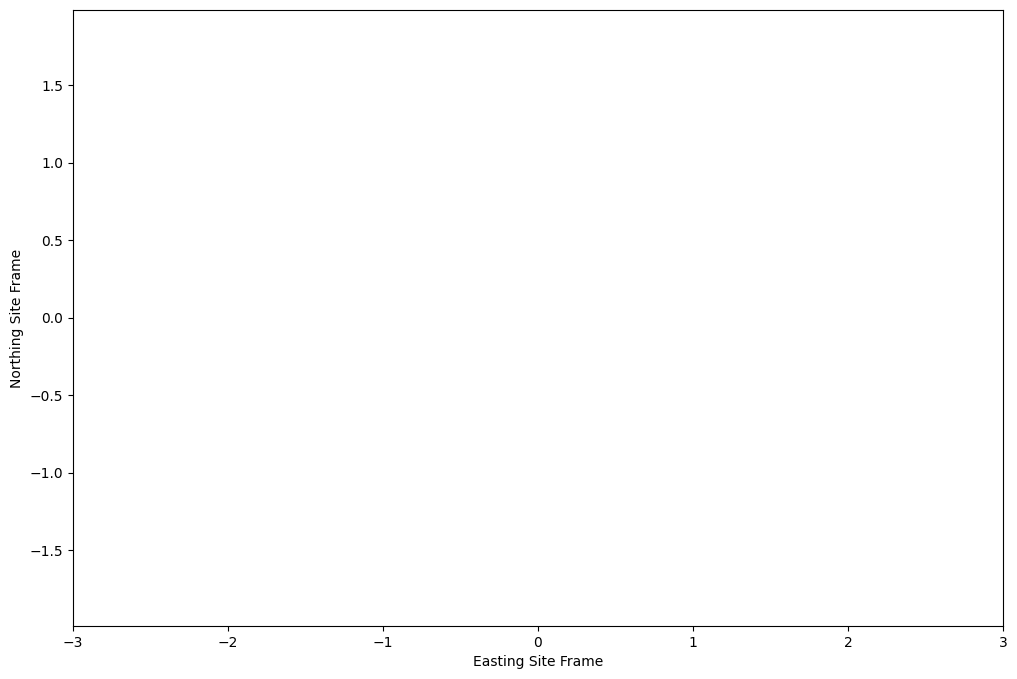

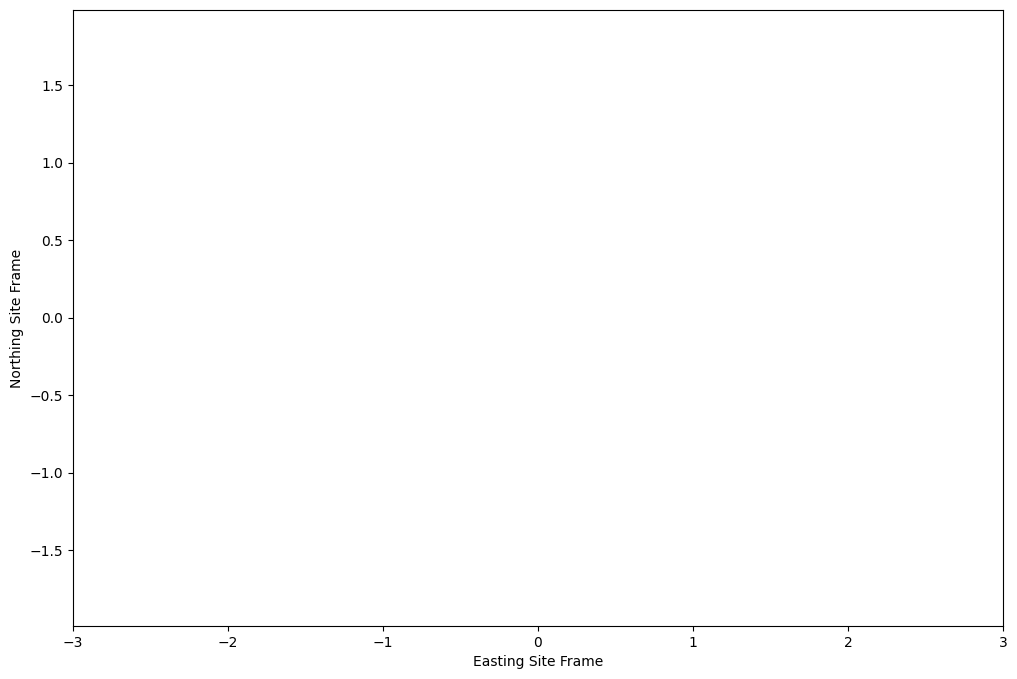

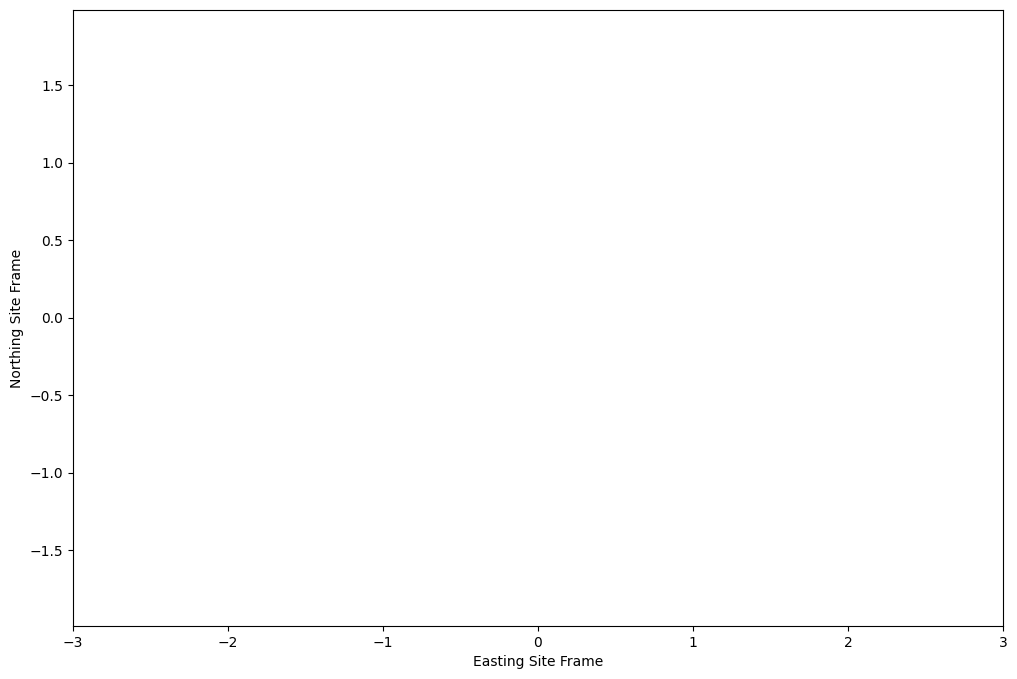

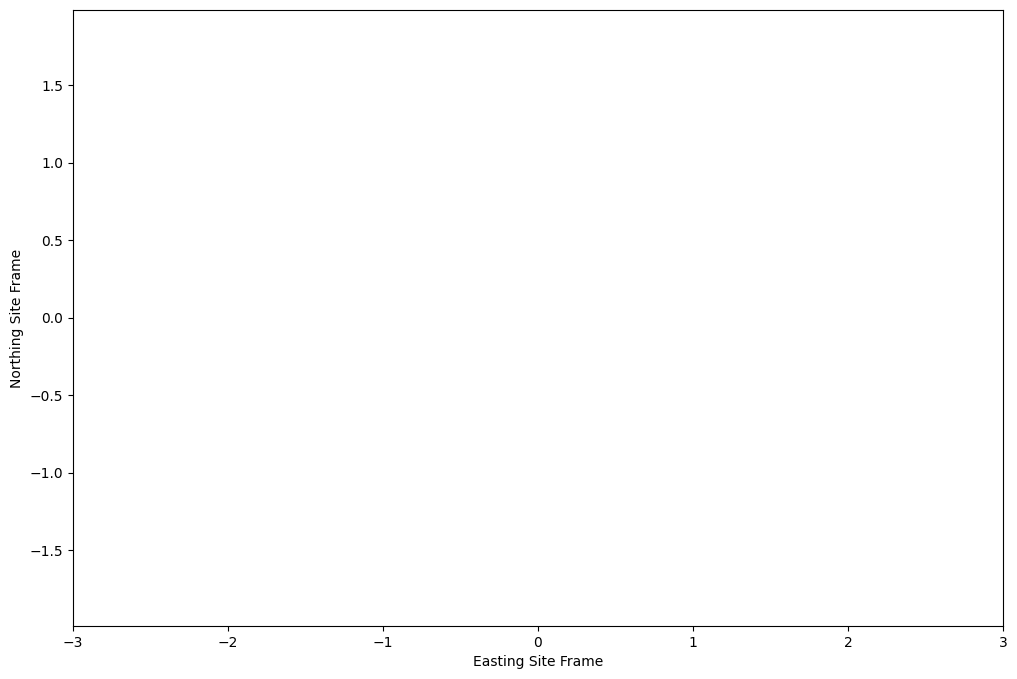

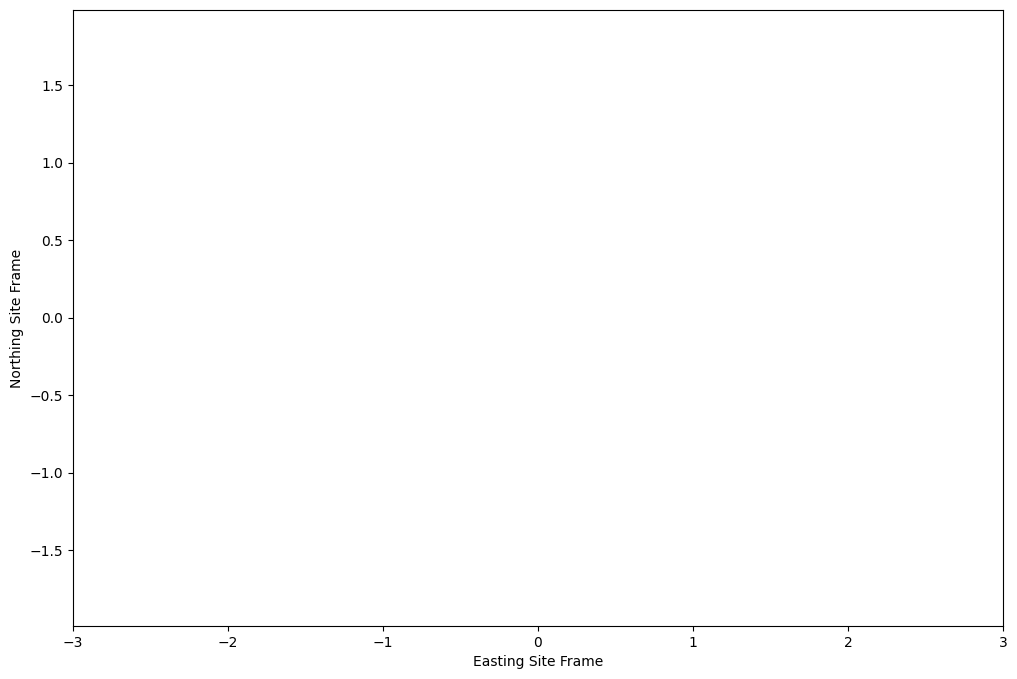

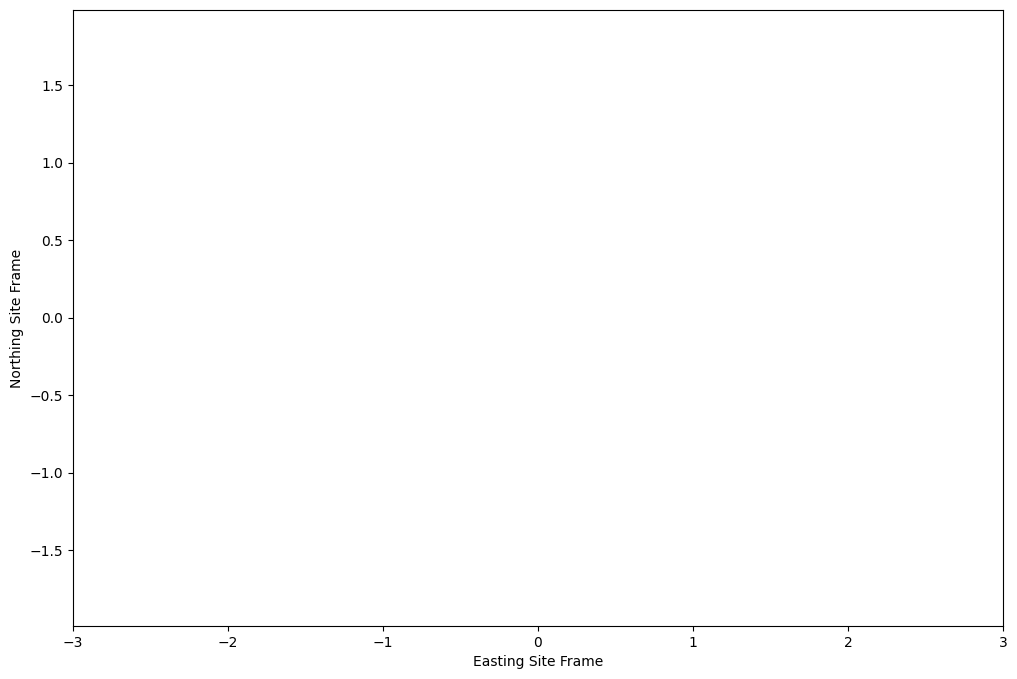

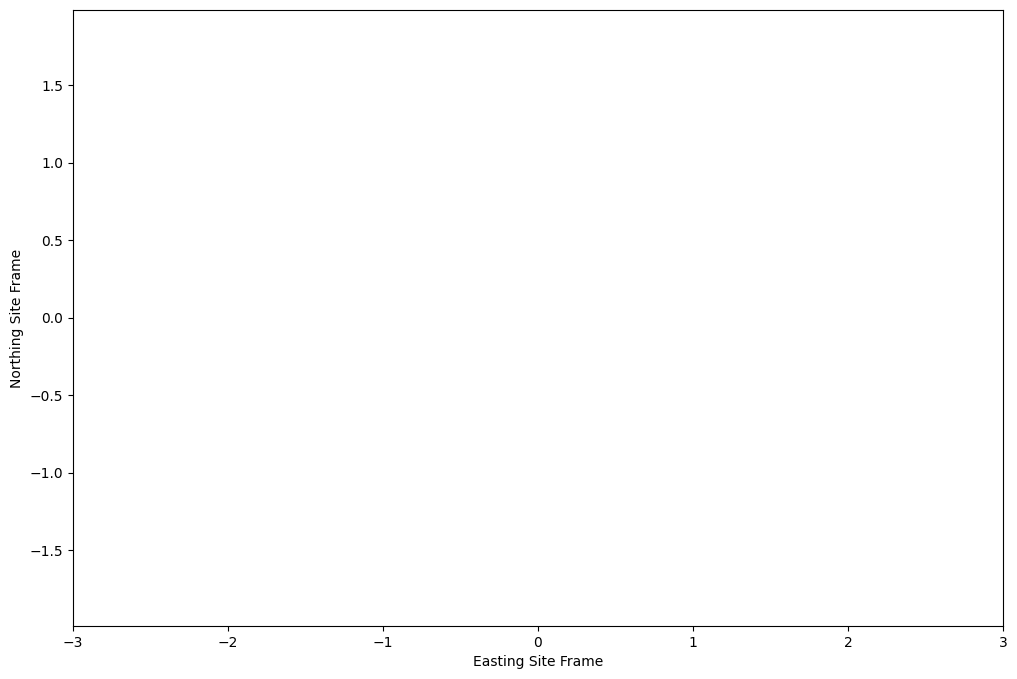

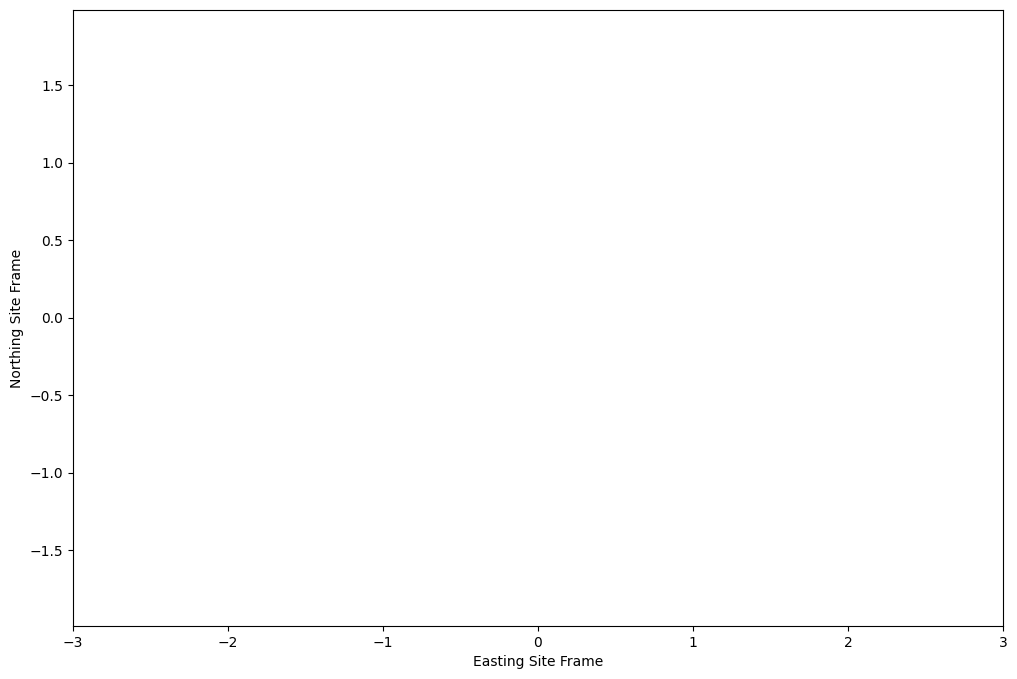

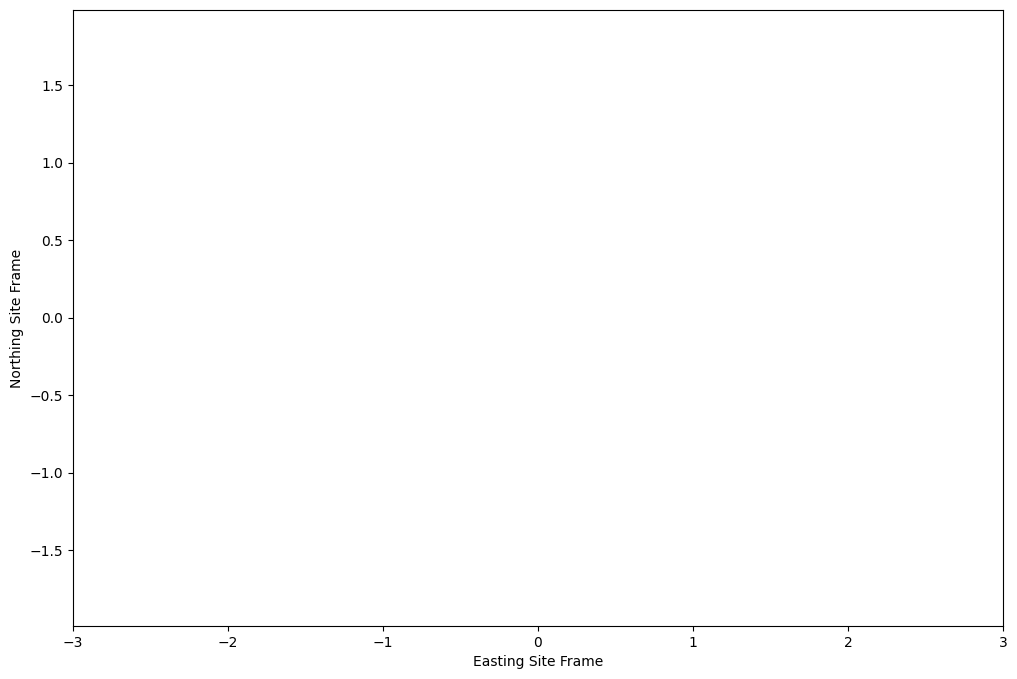

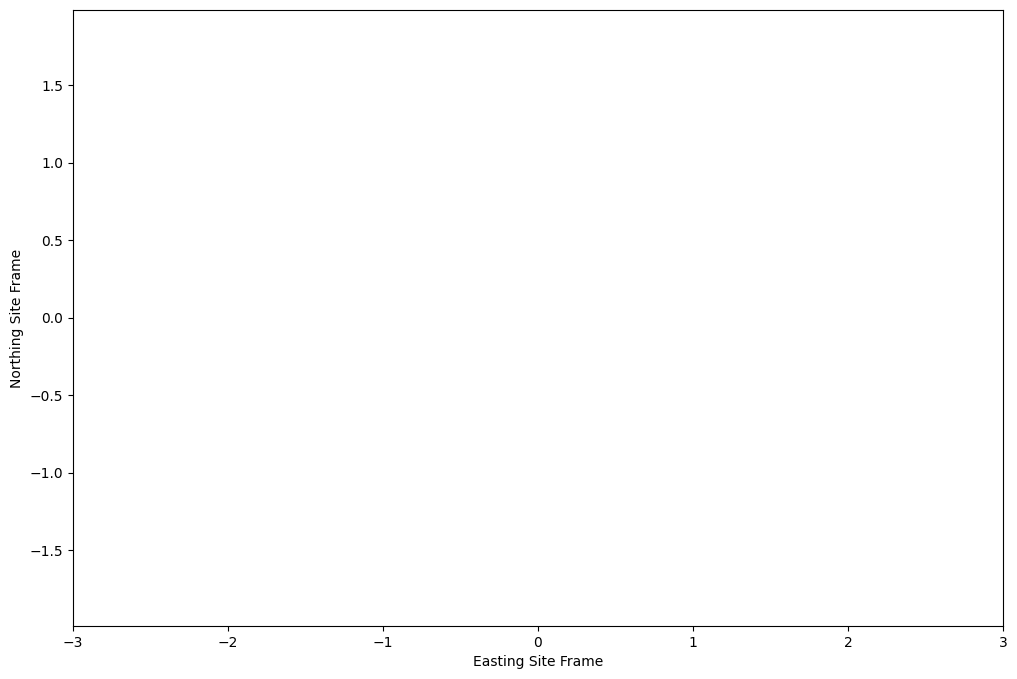

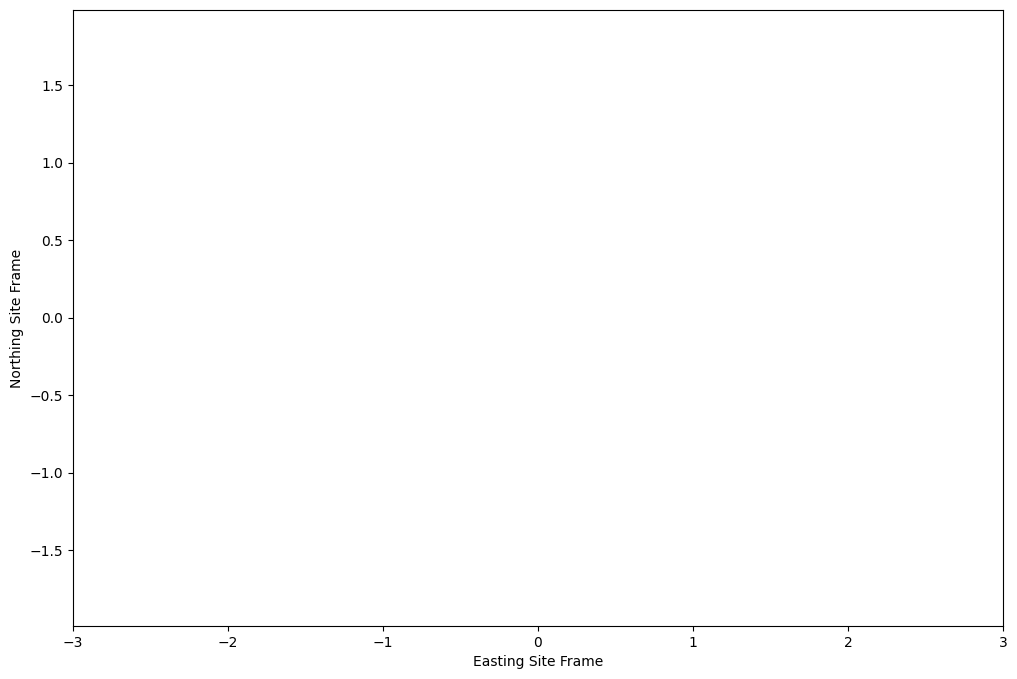

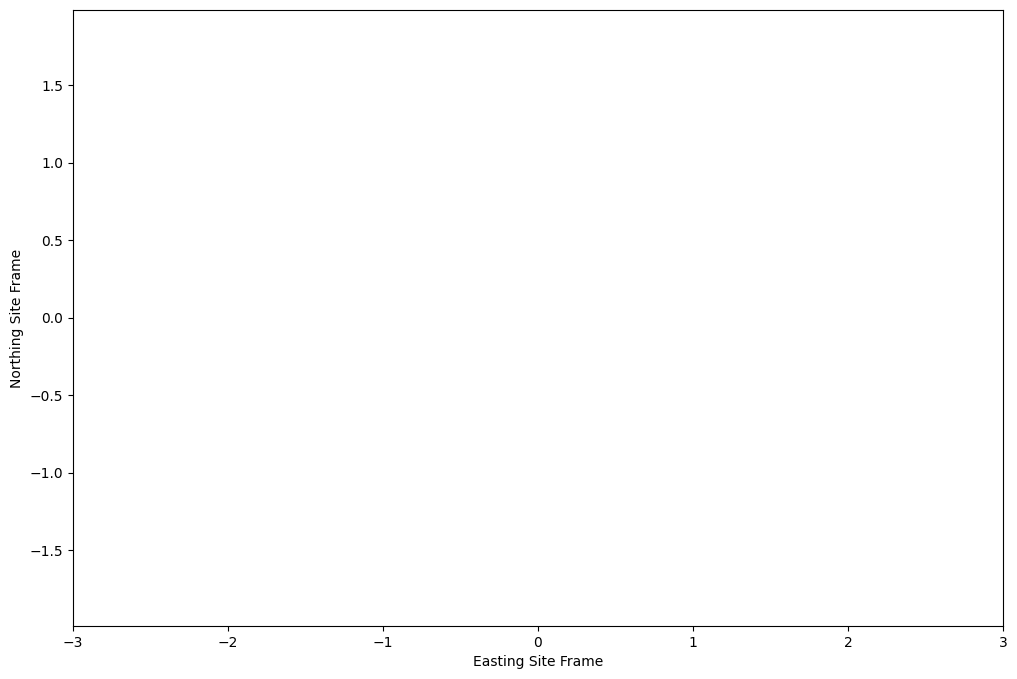

In [2]:
import glob


directory_output =  '../data/cal'
directory_output =  '../images'

IMG_paths = []
directory_inputs = ['../data/zcam', '../data/datadrive', '../data/datadrive/*/*/*/*']
sols = ['05*', '06*', '07*', '08*', '09*']

for sol in sols:
    for directory_input in directory_inputs:
        print(f"Processing Sols {sol}* in {directory_input}")
        try:
            IMG_paths = []
            suf = 'refs_'+str(sol)
            
            IMG_paths     += sorted( glob.glob(directory_input + f"/FLF_{sol}_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/FRF_{sol}_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/NLF_{sol}_*.IMG"))
            # IMG_paths     += sorted( glob.glob(directory_input + f"/NLMV_{sol}*_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/NRF_{sol}_*.IMG"))
            # IMG_paths     += sorted( glob.glob(directory_input + f"/NRMV_{sol}*_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/*/ZL0_{sol}_*.IMG"))
            IMG_paths     += sorted( glob.glob(directory_input + f"/*/ZR0_{sol}_*.IMG"))
        
            IMG_paths = IMG_paths[:]
            print( len(IMG_paths), 'images\n')
            if len(IMG_paths):
                processor.process_images(img_paths = IMG_paths,
                                    output_dir = directory_output,
                                    suf = suf.replace('*',''),
                                    find_offset_mode=False,
                                    frame = "site",
                                    angles = 'opk',
                                    save_im = True)
        except:
            print(f"FAILED TO PROCESS! sols:{sol}* in {directory_input}")

        print("="*100)